In [1]:
!pwd

/mnt/c/Users/vvasileiou/Desktop/test_lncAPNet/Pilot_3_TCGA_Breast/notebooks/Post-hoc_Analysis


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [3]:
# Load TSV file
rumma_geo = pd.read_csv("../../results/Rumma/Rumma_Geo.tsv", sep="\t")

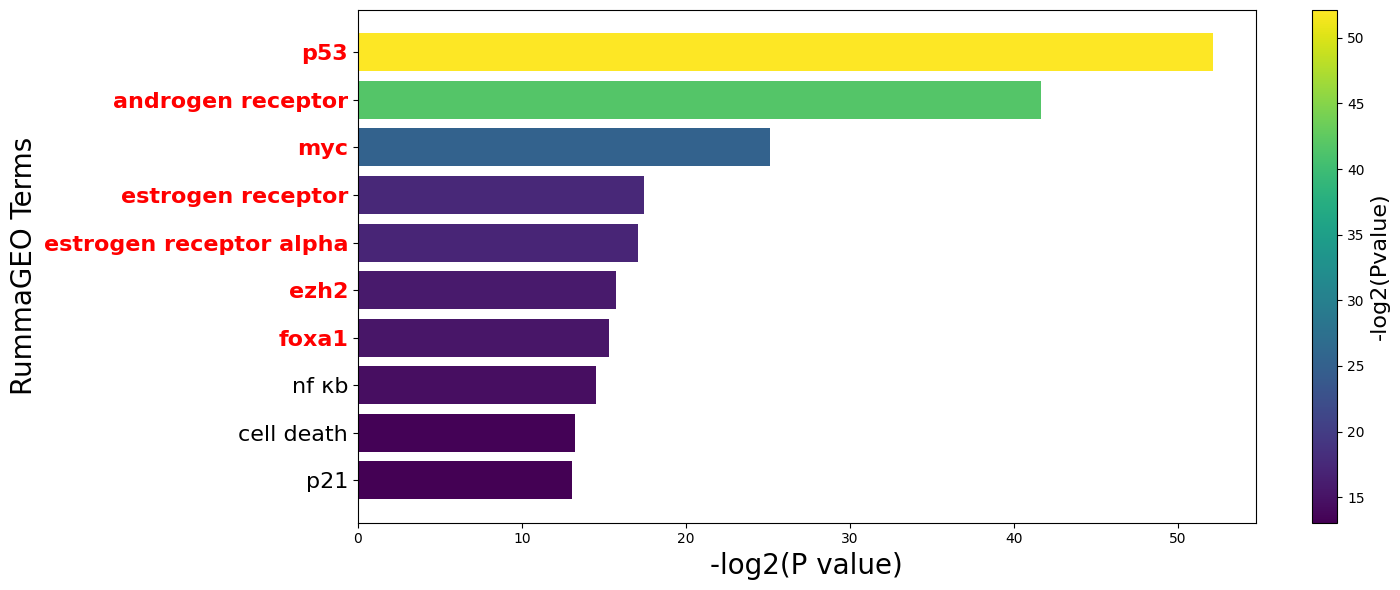

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import re

# -------------------------------------------------------------------
# Prepare dataset
# -------------------------------------------------------------------
rumma_geo["-log2(Pvalue)"] = -np.log2(rumma_geo["Pvalue"])

df_top10 = (
    rumma_geo
    .sort_values("-log2(Pvalue)", ascending=False)
    .head(10)
    .sort_values("-log2(Pvalue)", ascending=True)
)

# -------------------------------------------------------------------
# Clean up term names
# -------------------------------------------------------------------
def clean_term(term):
    term = re.sub(r"\s+MP:?\d+$", "", term)
    term = re.sub(r"\s+\(GO:[^)]+\)$", "", term)
    term = re.sub(r"\s+\(HP:[^)]+\)$", "", term)
    term = re.sub(r"\s+MEGAKARYOCYTES.*$", "", term, flags=re.IGNORECASE)
    term = re.sub(r"\s+MEGKA\w*$", "", term, flags=re.IGNORECASE)
    return term.strip()

df_top10["term_clean"] = df_top10["term"].apply(clean_term)

# -------------------------------------------------------------------
# Coloring
# -------------------------------------------------------------------
norm = mcolors.Normalize(
    vmin=df_top10["-log2(Pvalue)"].min(),
    vmax=df_top10["-log2(Pvalue)"].max()
)
cmap = cm.viridis

# Substrings matching key drivers of the basal-like TNBC phenotype
highlight_keywords = [
    "p53", 
    "androgen receptor", 
    "myc", 
    "estrogen receptor", 
    "ezh2", 
    "foxa1"
]

# -------------------------------------------------------------------
# Create figure
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(15, 6))

bars = ax.barh(
    df_top10["term_clean"],
    df_top10["-log2(Pvalue)"],
    color=cmap(norm(df_top10["-log2(Pvalue)"]))
)

# -------------------------------------------------------------------
# Highlight ONLY y-axis labels (not bars)
# -------------------------------------------------------------------
for label in ax.get_yticklabels():
    text = label.get_text().lower()
    label.set_fontsize(16)

    # Matches any substring from the highlight list
    if any(keyword in text for keyword in highlight_keywords):
        label.set_color("red")
        label.set_fontweight("bold")

# -------------------------------------------------------------------
# Labels and aesthetics
# -------------------------------------------------------------------
ax.set_xlabel("-log2(P value)", fontsize=20)
ax.set_ylabel("RummaGEO Terms", fontsize=20)

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, label="-log2(Pvalue)")
cbar.ax.yaxis.label.set_size(16)

plt.tight_layout()
fig.savefig("../../figures/RummaGEO_plot.png", dpi=300, bbox_inches="tight")
plt.show()
